In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thegoanpanda/fastag-fraud-detection-datesets-fictitious/FastagFraudDetection.csv


# EDA

In [2]:
df=pd.read_csv('/kaggle/input/datasets/thegoanpanda/fastag-fraud-detection-datesets-fictitious/FastagFraudDetection.csv')
df.head()


,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [3]:
#shape of data 
df.shape

(5000, 13)

In [4]:
#information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction_ID         5000 non-null   int64 
 1   Timestamp              5000 non-null   object
 2   Vehicle_Type           5000 non-null   object
 3   FastagID               4451 non-null   object
 4   TollBoothID            5000 non-null   object
 5   Lane_Type              5000 non-null   object
 6   Vehicle_Dimensions     5000 non-null   object
 7   Transaction_Amount     5000 non-null   int64 
 8   Amount_paid            5000 non-null   int64 
 9   Geographical_Location  5000 non-null   object
 10  Vehicle_Speed          5000 non-null   int64 
 11  Vehicle_Plate_Number   5000 non-null   object
 12  Fraud_indicator        5000 non-null   object
dtypes: int64(4), object(9)
memory usage: 507.9+ KB


In [5]:
#check the null value
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed
count,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,161.06200,141.261000,67.851200
std,1443.520003,112.44995,106.480996,16.597547
min,1.000000,0.00000,0.000000,10.000000
25%,1250.750000,100.00000,90.000000,54.000000
50%,2500.500000,130.00000,120.000000,67.000000
75%,3750.250000,290.00000,160.000000,82.000000
max,5000.000000,350.00000,350.000000,118.000000


In [8]:
#describe or get the statistical description for numerical+categorical features
df.describe(include='object')


,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Geographical_Location,Vehicle_Plate_Number,Fraud_indicator
count,5000,5000,4451,5000,5000,5000,5000,5000,5000
unique,4423,7,4451,6,2,3,5,5000,2
top,1/1/2023 8:15,Bus,FTG-459-WSX-543,B-102,Regular,Large,"13.059816123454882, 77.77068662374292",KA37AB3456,Not Fraud
freq,5,716,1,1432,2858,2144,1000,1,4017


#### Observation 1
1. FatagID has 549 null values
2. No duplicate values/entries
3. Data types are almost correct


In [9]:
df.columns

Index(['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID',
       'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount',
       'Amount_paid', 'Geographical_Location', 'Vehicle_Speed',
       'Vehicle_Plate_Number', 'Fraud_indicator'],
      dtype='object')

In [10]:
print("Unique Vehicle_Type:",df['Vehicle_Type'].unique())
print("Unique TollBoothID:",df['TollBoothID'].unique())  
print("Unique Lane_Type:",df['Lane_Type'].unique())
print("Unique Timestamp:",df['Timestamp'].unique())
print("Geographical_Location:",df['Geographical_Location'].unique())
print("Unique Fraud_indicator:",df['Fraud_indicator'].unique())
print("Unique Vehicle_Dimensions:",df['Vehicle_Dimensions'].unique())


Unique Vehicle_Type: ['Bus ' 'Car' 'Motorcycle' 'Truck' 'Van' 'Sedan' 'SUV']
Unique TollBoothID: ['A-101' 'B-102' 'D-104' 'C-103' 'D-105' 'D-106']
Unique Lane_Type: ['Express' 'Regular']
Unique Timestamp: ['1/6/2023 11:20' '1/7/2023 14:55' '1/8/2023 18:25' ... '2/5/2023 5:08'
 '2/20/2023 20:34' '3/10/2023 0:59']
Geographical_Location: ['13.059816123454882, 77.77068662374292'
 '13.042660878688794, 77.47580097259879'
 '12.84197701525119, 77.67547528176169'
 '12.936687032945434, 77.53113977439017'
 '13.21331620748757, 77.55413526894684']
Unique Fraud_indicator: ['Fraud' 'Not Fraud']
Unique Vehicle_Dimensions: ['Large' 'Small' 'Medium']


# Data Visualisation

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64


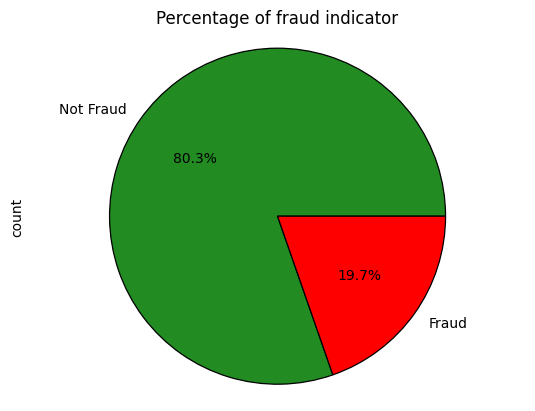

In [12]:
print(df['Fraud_indicator'].value_counts())
df['Fraud_indicator'].value_counts().plot(kind='pie', autopct= '%1.1f%%', colors=['forestgreen','red'],wedgeprops = {"edgecolor" : "black",
                      'linewidth': 0.9,
                      'antialiased': True})
plt.title("Percentage of fraud indicator")
plt.axis('equal')
plt.show()

# Analyse different columns

Analysise based on fraud indicator

In [13]:
df['Vehicle_Type'].value_counts()

Vehicle_Type
Bus           716
Car           714
Motorcycle    714
Truck         714
Van           714
Sedan         714
SUV           714
Name: count, dtype: int64

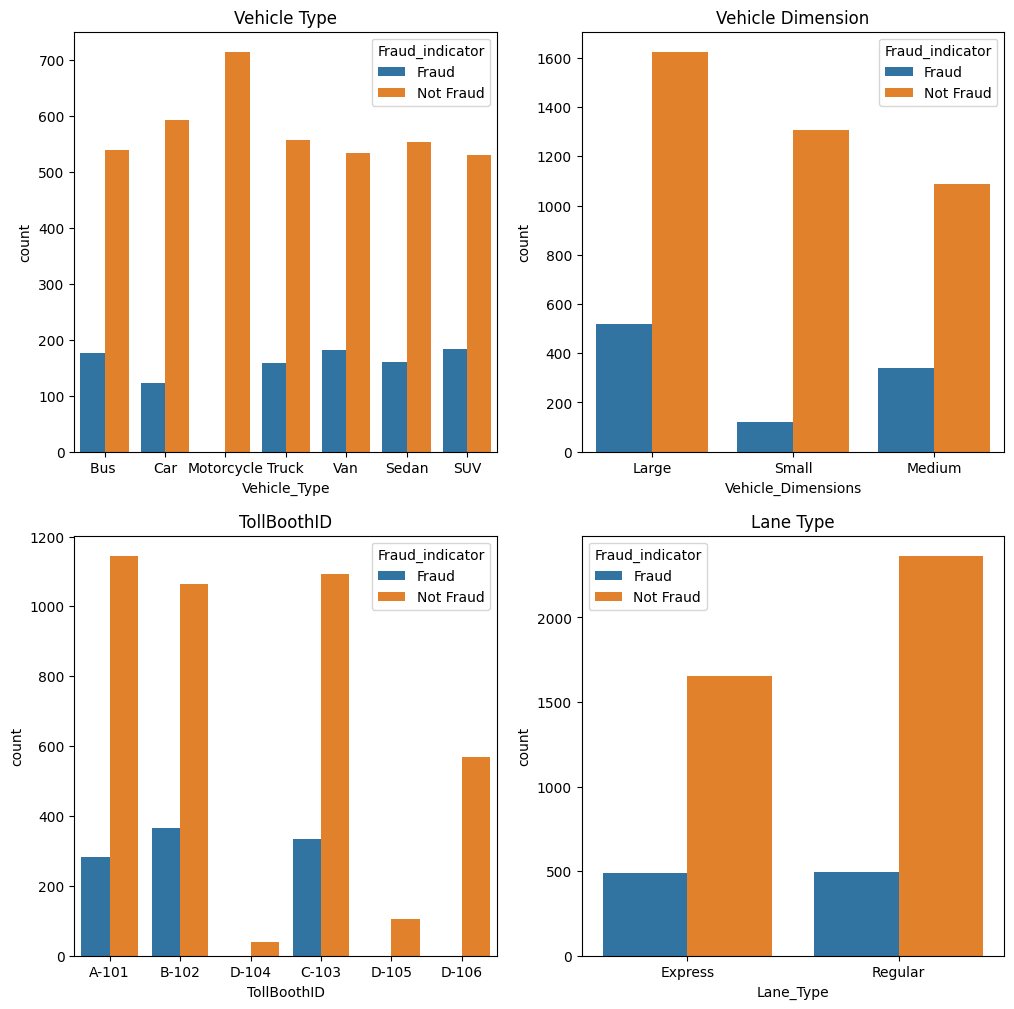

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [14]:

fig, axes = plt.subplots(2,2, figsize=(12,12))
# Vehicle Type
sns.countplot(x='Vehicle_Type', data=df, hue='Fraud_indicator', ax= axes[0,0]).set_title('Vehicle Type')
# Vehicle Dimension
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Dimensions', data=df, hue='Fraud_indicator', ax=axes[0,1]).set_title('Vehicle Dimension')
# Toll Booth Id
plt.figure(figsize=(6,5))
sns.countplot(x='TollBoothID', data=df, hue='Fraud_indicator', ax= axes[1,0]).set_title('TollBoothID')
# Lane Type
plt.figure(figsize=(6,4))
sns.countplot(x='Lane_Type', data=df, hue='Fraud_indicator', ax= axes[1,1]).set_title('Lane Type')

plt.tight_layout()

#### Observation 2
1. Motorcycles are clan - not involved in any fraud
2. TollBooths 184 , 105 and 106 have not fraud detected. But 101,102,103 have mix data
3. Express way has higher fraud percentage based on vehicles than regular ways
4. Very less small vehicles are involves in fraud


In [15]:
df.columns

Index(['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID',
       'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount',
       'Amount_paid', 'Geographical_Location', 'Vehicle_Speed',
       'Vehicle_Plate_Number', 'Fraud_indicator'],
      dtype='object')

## Distribution of transaction amount

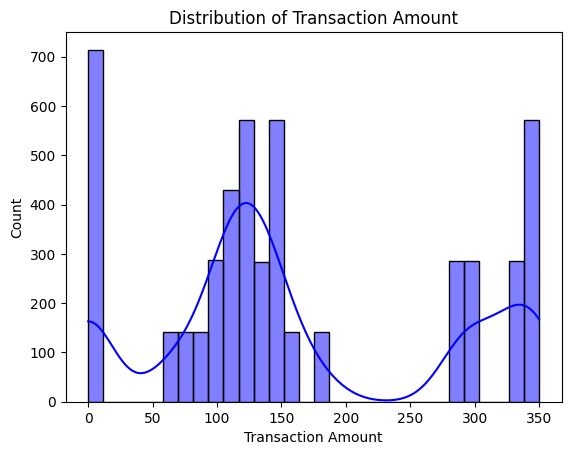

In [16]:
sns.histplot(df['Transaction_Amount'], bins=30, kde=True, color='blue', edgecolor='black')
plt.title("Distribution of Transaction Amount")
plt.xlabel('Transaction Amount')
plt.ylabel('Count')
plt.show()

## distribution of paid amount 


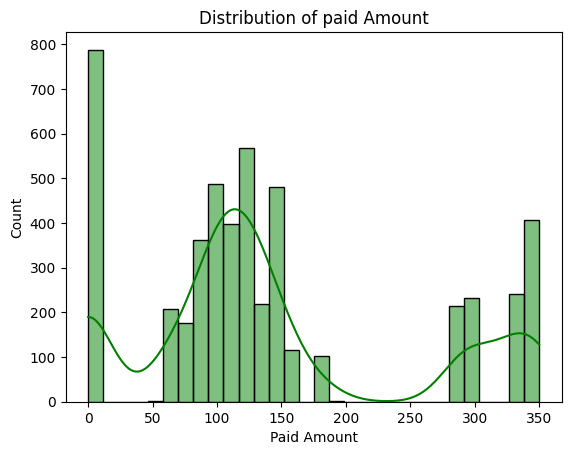

In [17]:
sns.histplot(df['Amount_paid'],bins=30, kde= True, color='green',edgecolor= 'black')
plt.title("Distribution of paid Amount")
plt.xlabel('Paid Amount')
plt.ylabel('Count')
plt.show()


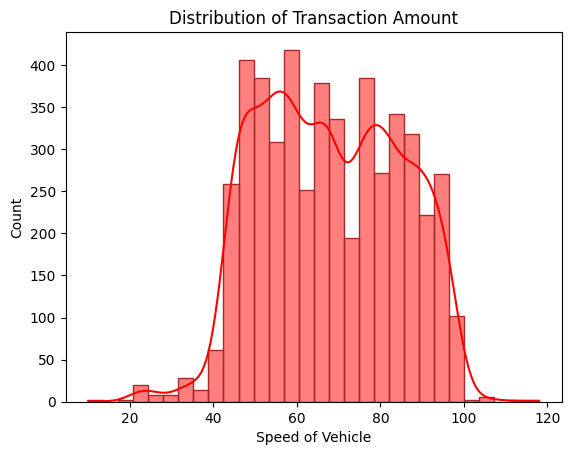

In [18]:
sns.histplot(df['Vehicle_Speed'], bins=30, kde=True, color='red', edgecolor='brown')
plt.title("Distribution of Transaction Amount")
plt.xlabel('Speed of Vehicle')
plt.ylabel('Count')
plt.show()

### Relationship between Transaction and Paid amount

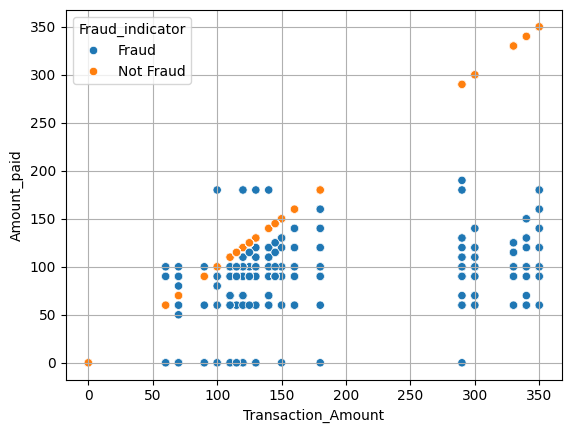

In [19]:
sns.scatterplot(x='Transaction_Amount',
            y= 'Amount_paid',
            hue='Fraud_indicator', data=df)
plt.grid()

#### Observation 3
1. When transaction amount is not equal to amount paid ==> Fraud
2. When transaction amount is equal to amount paid ==> Not Fraud

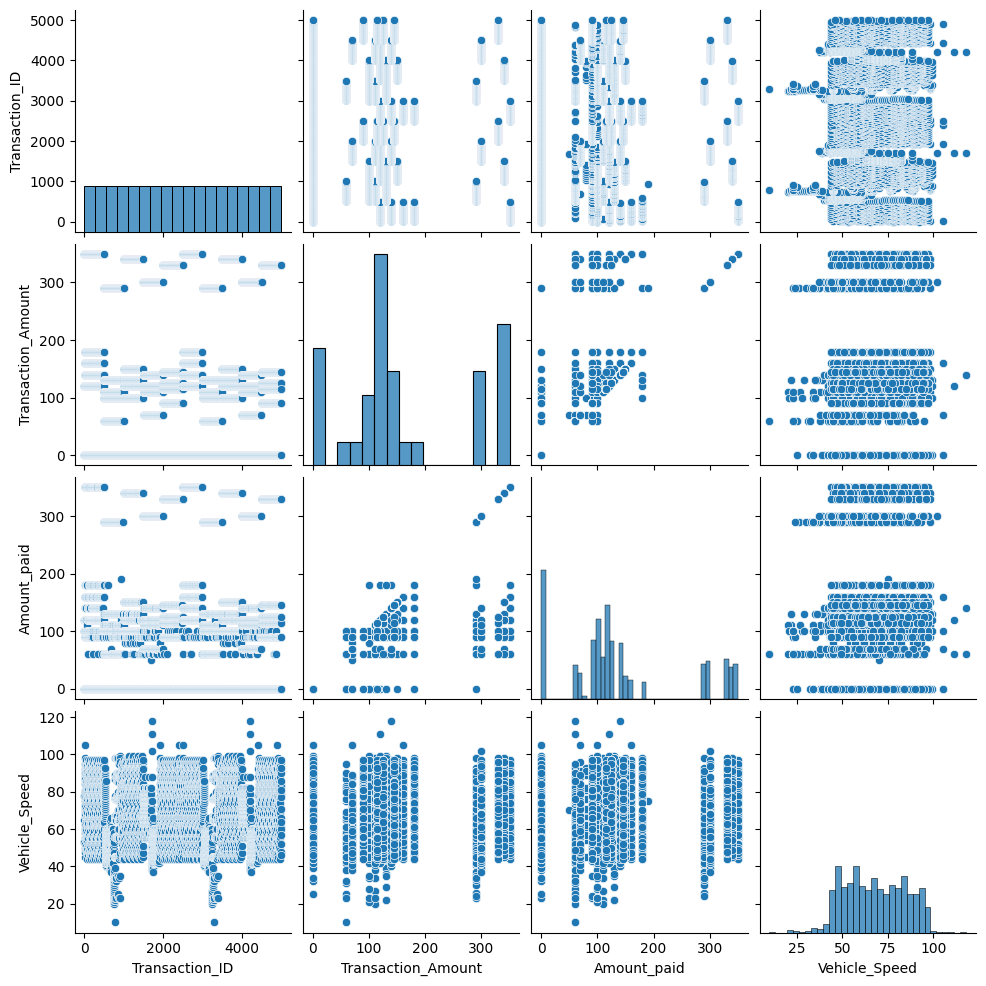

In [20]:
#pair plot
sns.pairplot(df)

## Feature Extraction

In [21]:
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

In [22]:
df['state_code']=df['Vehicle_Plate_Number'].str[:2]
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator,state_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud,KA


In [23]:
## remove vehicle number plate feature
df=df.drop('Vehicle_Plate_Number',axis=1)
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,state_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,KA


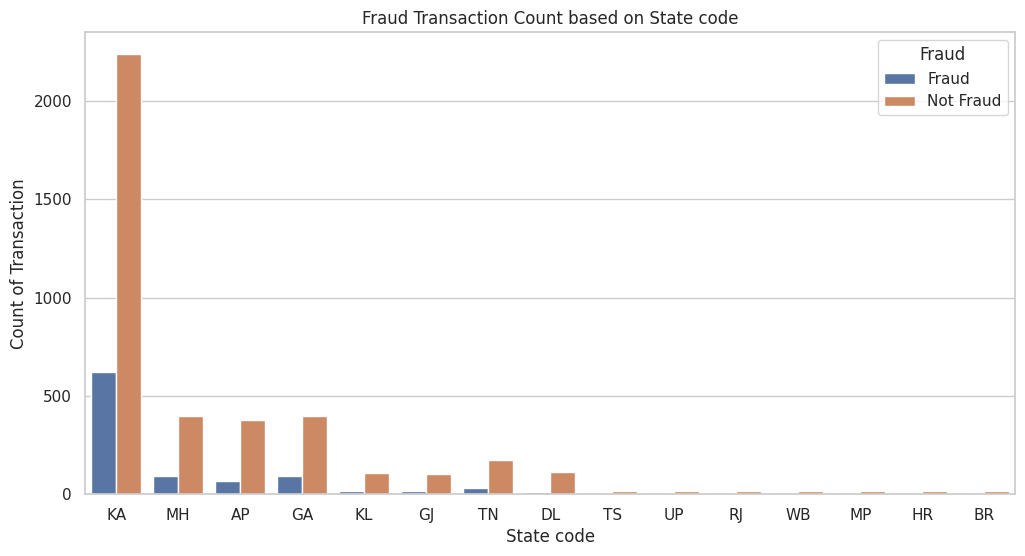

In [24]:
# visualize fraud based on state code
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6))
sns.countplot(x='state_code',
             data=df,
             hue='Fraud_indicator')
plt.title('Fraud Transaction Count based on State code')
plt.xlabel('State code')
plt.ylabel('Count of Transaction')
plt.legend(title='Fraud')
plt.show()

In [25]:
df['state_code'].value_counts()

state_code
KA    2860
GA     489
MH     488
AP     447
TN     203
DL     123
KL     121
GJ     119
TS      22
UP      22
RJ      22
WB      21
MP      21
HR      21
BR      21
Name: count, dtype: int64

In [26]:
df.loc[df['Fraud_indicator']=='Fraud','state_code'].value_counts()

state_code
KA    623
GA     93
MH     92
AP     68
TN     31
GJ     16
KL     14
DL     12
TS      8
RJ      7
BR      6
HR      5
UP      4
WB      2
MP      2
Name: count, dtype: int64

### Observaton 4
1. Highest Fraud count is in Karnataka(KA)

In [27]:
#analyse Timestamp to get the fraud/not fraud based on days
df['Timestamp']

0        1/6/2023 11:20
1        1/7/2023 14:55
2        1/8/2023 18:25
3         1/9/2023 2:05
4        1/10/2023 6:35
             ...       
4995     1/1/2023 22:18
4996    1/17/2023 13:43
4997      2/5/2023 5:08
4998    2/20/2023 20:34
4999     3/10/2023 0:59
Name: Timestamp, Length: 5000, dtype: object

In [28]:
df['Timestamp']= pd.to_datetime(df['Timestamp'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Transaction_ID         5000 non-null   int64         
 1   Timestamp              5000 non-null   datetime64[ns]
 2   Vehicle_Type           5000 non-null   object        
 3   FastagID               4451 non-null   object        
 4   TollBoothID            5000 non-null   object        
 5   Lane_Type              5000 non-null   object        
 6   Vehicle_Dimensions     5000 non-null   object        
 7   Transaction_Amount     5000 non-null   int64         
 8   Amount_paid            5000 non-null   int64         
 9   Geographical_Location  5000 non-null   object        
 10  Vehicle_Speed          5000 non-null   int64         
 11  Fraud_indicator        5000 non-null   object        
 12  state_code             5000 non-null   object        
dtypes: 

In [30]:
df['Hour']=df['Timestamp'].dt.hour
df['DayOfWeek']=df['Timestamp'].dt.dayofweek
df['Month']=df['Timestamp'].dt.month
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,state_code,Hour,DayOfWeek,Month
0,1,2023-01-06 11:20:00,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,KA,11,4,1
1,2,2023-01-07 14:55:00,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,KA,14,5,1
2,3,2023-01-08 18:25:00,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,KA,18,6,1
3,4,2023-01-09 02:05:00,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,KA,2,0,1
4,5,2023-01-10 06:35:00,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,KA,6,1,1


In [31]:
#drop time stamp feature
df=df.drop('Timestamp',axis=1)

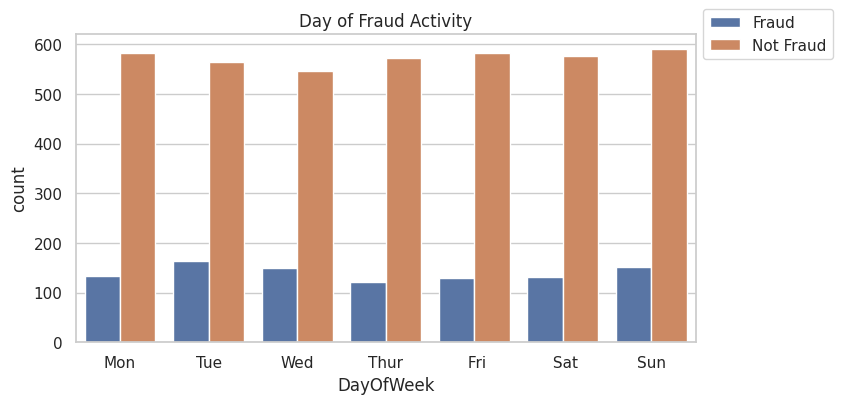

In [32]:
#visualise based on 
plt.figure(figsize=(8,4))
sns. countplot(data=df,
             x='DayOfWeek',
              hue='Fraud_indicator')
plt.title('Day of Fraud Activity')
plt.legend(loc='center left',bbox_to_anchor=(1,1))
plt.xticks([0,1,2,3,4,5,6],['Mon', 'Tue', 'Wed', 'Thur',' Fri',' Sat', 'Sun'])
plt.show()

### Correlation Matrix

In [33]:
numericaldf=df.select_dtypes('number') #only numerical data

In [34]:
corr_matrix=numericaldf.corr()
corr_matrix

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed,Hour,DayOfWeek,Month
Transaction_ID,1.000000,-0.023515,0.044433,0.014378,-0.023208,0.002446,0.260075
Transaction_Amount,-0.023515,1.000000,0.870078,0.053229,-0.036980,-0.001813,-0.019824
Amount_paid,0.044433,0.870078,1.000000,0.039027,-0.026358,-0.002960,0.018105
Vehicle_Speed,0.014378,0.053229,0.039027,1.000000,-0.002259,-0.017608,0.015349
Hour,-0.023208,-0.036980,-0.026358,-0.002259,1.000000,-0.010292,0.001041
DayOfWeek,0.002446,-0.001813,-0.002960,-0.017608,-0.010292,1.000000,0.002552
Month,0.260075,-0.019824,0.018105,0.015349,0.001041,0.002552,1.000000


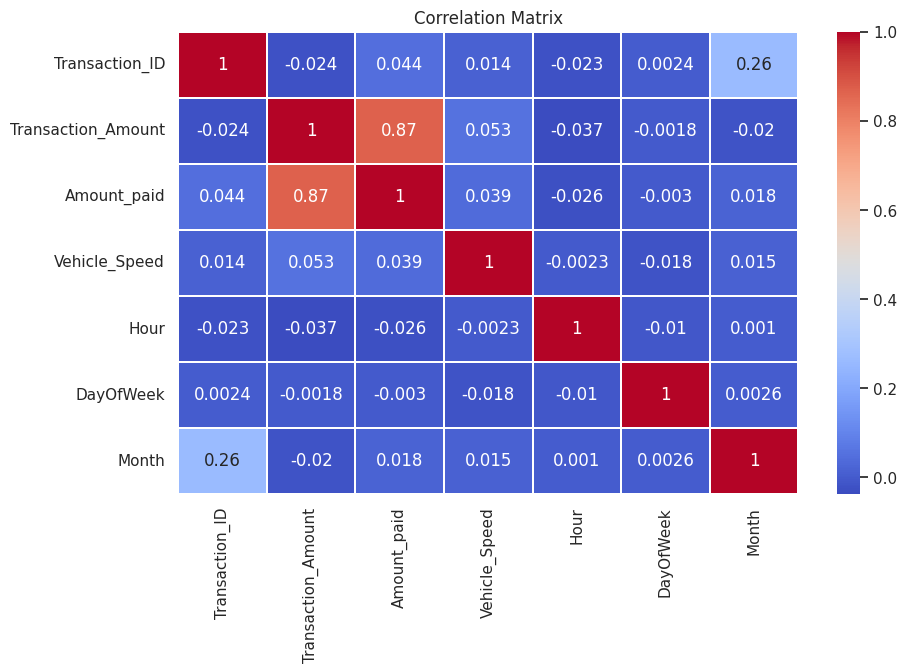

In [35]:
#plot correlation 
plt.figure(figsize=(10,6))
sns. heatmap(corr_matrix,
           cmap='coolwarm', annot=True, linewidths=.1)
plt.title('Correlation Matrix')
plt.show()

In [36]:
df.columns


Index(['Transaction_ID', 'Vehicle_Type', 'FastagID', 'TollBoothID',
       'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid',
       'Geographical_Location', 'Vehicle_Speed', 'Fraud_indicator',
       'state_code', 'Hour', 'DayOfWeek', 'Month'],
      dtype='object')

In [37]:
# remove unnecessary columns
df.drop(['Transaction_ID','FastagID','Geographical_Location'], axis=1, inplace =True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Vehicle_Type        5000 non-null   object
 1   TollBoothID         5000 non-null   object
 2   Lane_Type           5000 non-null   object
 3   Vehicle_Dimensions  5000 non-null   object
 4   Transaction_Amount  5000 non-null   int64 
 5   Amount_paid         5000 non-null   int64 
 6   Vehicle_Speed       5000 non-null   int64 
 7   Fraud_indicator     5000 non-null   object
 8   state_code          5000 non-null   object
 9   Hour                5000 non-null   int32 
 10  DayOfWeek           5000 non-null   int32 
 11  Month               5000 non-null   int32 
dtypes: int32(3), int64(3), object(6)
memory usage: 410.3+ KB


In [39]:
# label encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [40]:
objectColumns= ['Vehicle_Type','Lane_Type','TollBoothID','Vehicle_Dimensions','state_code','Fraud_indicator']
label_encoder={}
for column in objectColumns:
    le=LabelEncoder()
    df[column]=le.fit_transform(df[column])
    label_encoder[column]= le


In [41]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,state_code,Hour,DayOfWeek,Month
0,0,0,0,0,350,120,65,0,6,11,4,1
1,1,1,1,2,120,100,78,0,6,14,5,1
2,2,3,1,2,0,0,53,1,6,18,6,1
3,5,2,1,0,350,120,92,0,6,2,0,1
4,6,1,0,1,140,100,60,0,6,6,1,1


In [42]:
label_encoder['Lane_Type'].classes_

array(['Express', 'Regular'], dtype=object)

# Model Training

In [43]:
X=df.drop(columns=['Fraud_indicator'])
y=df['Fraud_indicator']

In [44]:
#split the x and y for train and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [45]:
print("X_Train:",X_train.shape)
print("X_Test:",X_test.shape)
print("y_Train:",y_train.shape)
print("y_Test:",y_test.shape)

X_Train: (3500, 11)
X_Test: (1500, 11)
y_Train: (3500,)
y_Test: (1500,)


# Logistic Regression Model

In [46]:
from sklearn.linear_model import LogisticRegression
lr_model =  LogisticRegression(max_iter=2000)
lr_model 

LogisticRegression(max_iter=2000)

In [47]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [48]:
#Predict 
y_pred=lr_model.predict(X_test)
print(y_pred)

[1 1 1 ... 1 1 1]


## Model Evaluation

In [49]:
## import libraries from matrics
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [50]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)
precision= precision_score(y_test,y_pred)
recall= recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("LR model results: ")
print("\nAccuracy: ",accuracy)
print("\nConfusion Matrix: ",conf_matrix)
print("\nPrecision score: ",precision)
print("\nRecall score: ",recall)
print("\nF1 score: ",f1)

LR model results: 

Accuracy:  0.98

Confusion Matrix:  [[ 297   30]
 [   0 1173]]

Precision score:  0.9750623441396509

Recall score:  1.0

F1 score:  0.9873737373737373


In [51]:
#classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       327
           1       0.98      1.00      0.99      1173

    accuracy                           0.98      1500
   macro avg       0.99      0.95      0.97      1500
weighted avg       0.98      0.98      0.98      1500



In [52]:
def evaluate_model(y_test,y_pred):
   accuracy = accuracy_score(y_test, y_pred)
   conf_matrix = confusion_matrix(y_test,y_pred)
   precision= precision_score(y_test,y_pred)
   recall= recall_score(y_test,y_pred)
   f1 = f1_score(y_test,y_pred)


   print("\nAccuracy: ",accuracy)
   print("\nConfusion Matrix: ",conf_matrix)
   print("\nPrecision score: ",precision)
   print("\nRecall score: ",recall)
   print("\nF1 score: ",f1)
    

In [53]:
 # testing all models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Decision Tree

In [54]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train,y_train)

y_tree_pred= tree_model.predict(X_test)
y_tree_pred

array([1, 1, 1, ..., 1, 1, 1])

In [55]:
#Accuracy of Decision Tree
print("Desicion tree model evaluation: \n")
evaluate_model(y_test, y_tree_pred)

Desicion tree model evaluation: 


Accuracy:  0.9986666666666667

Confusion Matrix:  [[ 325    2]
 [   0 1173]]

Precision score:  0.9982978723404256

Recall score:  1.0

F1 score:  0.9991482112436116


# Random Forest

In [56]:
# Random Forest
rf_model=RandomForestClassifier()
rf_model.fit(X_train,y_train)
rf_y_pred=rf_model.predict(X_test)

#accuracy
print("Random Forest model evaluation: \n")
evaluate_model(y_test, rf_y_pred)

Random Forest model evaluation: 


Accuracy:  0.984

Confusion Matrix:  [[ 303   24]
 [   0 1173]]

Precision score:  0.9799498746867168

Recall score:  1.0

F1 score:  0.9898734177215189


# Support Vector Machine


In [57]:
from sklearn.svm import SVC
svc_model=SVC()
svc_model.fit(X_train,y_train)

SVC()

In [58]:
svc_y_pred = svc_model.predict(X_test)

#accuracy
print("Support Vector Classifier model evaluation: \n")
evaluate_model(y_test, svc_y_pred)

Support Vector Classifier model evaluation: 


Accuracy:  0.9793333333333333

Confusion Matrix:  [[ 296   31]
 [   0 1173]]

Precision score:  0.9742524916943521

Recall score:  1.0

F1 score:  0.9869583508624317


# KNN

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knnModel=KNeighborsClassifier(n_neighbors = 3)
knnModel.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [60]:
knn_y_pred=knnModel.predict(X_test)

#accuracy
print("KNN Classifier model evaluation: \n")
evaluate_model(y_test, knn_y_pred)

KNN Classifier model evaluation: 


Accuracy:  0.9873333333333333

Confusion Matrix:  [[ 308   19]
 [   0 1173]]

Precision score:  0.9840604026845637

Recall score:  1.0

F1 score:  0.9919661733615222


Text(0.5, 1.0, 'Comparision of accuracy scores of different models')

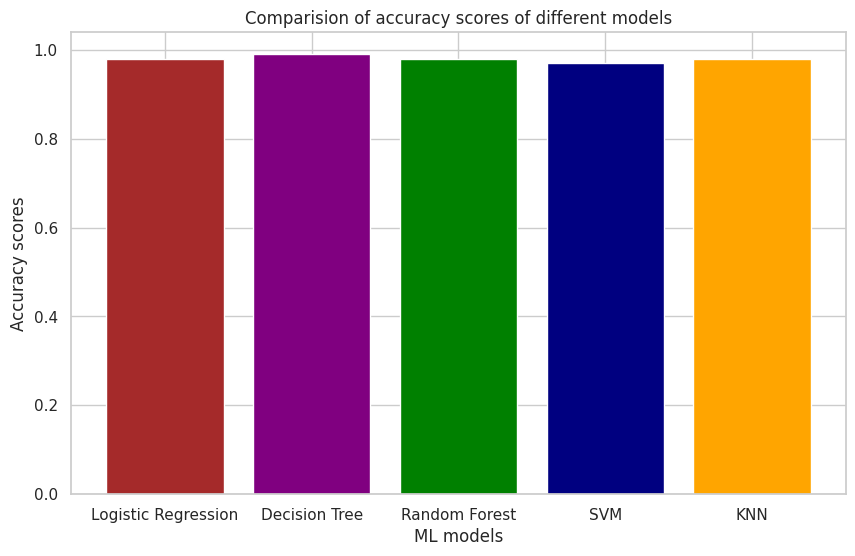

In [61]:
#visualize

models = ['Logistic Regression','Decision Tree','Random Forest','SVM','KNN']
accuracy_scores = [0.98,0.99,0.98,0.97,0.98]
colors = ['brown','purple','green','navy','orange']
plt.figure(figsize=(10,6))
plt.bar(models, accuracy_scores, color=colors)
plt.xlabel("ML models")
plt.ylabel("Accuracy scores")
plt.title("Comparision of accuracy scores of different models")


# Conclusion 
1. Decision Tree
    - highest accuracy (99%)
    - overall top-performing model
2. SVM
   - least accuracy (97%)

In [62]:
import joblib
joblib.dump(lr_model, "/kaggle/working/model.pkl")

['/kaggle/working/model.pkl']

In [63]:
import os
os.listdir("/kaggle/working")

['model.pkl', '__notebook__.ipynb']